### 적정 수수료 책정:

거래 지속성을 확보할 수 있도록, 전문가와 고객 간의 거래를 촉진하는 적정 수수료 구조를 제안합니다.

현황: 


동종업계의 공격적인 마케팅


IT전문가들 이탈


서비스간 적정가격 책정의 부재로 고객불만 증가


아웃소싱 거래가 어플리케이션 외의 개인적인 연락으로 전환되어 거래 지속성 감소. 


이로 인한 거래 성사율 정체 및 전문가 이탈 심화되면 수수료 기반 매출유지 어려울 것으로 우려됨.


거래 성사율 개선 및 적정 수수료 책정방안 도출 시급.

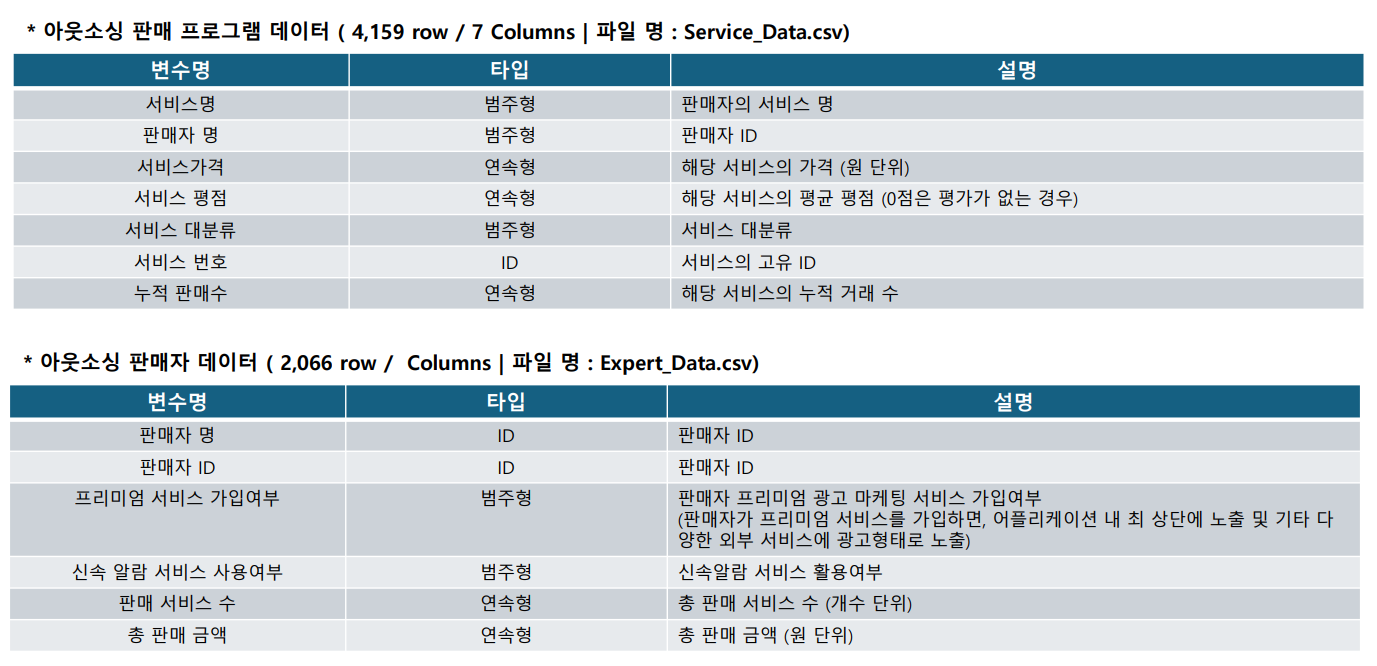

In [1]:
import pandas as pd

df1 = pd.read_csv("Service_Data.csv")
df1.head(3)

,서비스명,판매자,서비스가격,평점,대분류,서비스번호,판매수
0,"""P2P 대출"" 서비스를 위한 기획을 해 드립니다.",디자인쇼크리더,400000.0,0.0,기획,5651.0,6
1,"""반응형 웹 퍼블리싱"" 모든 퍼블리싱 작업 맞춤 진행",ThunDesign,15000.0,0.0,홈페이지,6122.0,1
2,"""이커머스 웹 사이트개발 경력자""의 쇼핑몰 제작",IAMTRY,500000.0,0.0,커머스,6152.0,3


In [2]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4159 entries, 0 to 4158
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   서비스명    4158 non-null   object 
 1   판매자     4158 non-null   object 
 2   서비스가격   4158 non-null   float64
 3   평점      4158 non-null   float64
 4   대분류     4158 non-null   object 
 5   서비스번호   4158 non-null   float64
 6   판매수     4159 non-null   int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 227.6+ KB


In [3]:
df1[df1['판매자']=='디자인쇼크리더']

,서비스명,판매자,서비스가격,평점,대분류,서비스번호,판매수
0,"""P2P 대출"" 서비스를 위한 기획을 해 드립니다.",디자인쇼크리더,400000.0,0.0,기획,5651.0,6
539,영업사원 홍보용 개인 홈페이지 만들어 드립니다.,디자인쇼크리더,400000.0,0.0,홈페이지,5650.0,47
2662,섬세하게 디자인된 반응형 웹사이트 제작해 드립니다.,디자인쇼크리더,200000.0,0.0,홈페이지,5652.0,13


In [4]:
df2 = pd.read_csv("Expert_Data.csv")
df2.head(3)

,판매자ID,판매자,판매 서비스 수,총 판매 금액,프리미엄 서비스 가입여부,신속 알람 서비스 사용여부
0,V2_0,김러그,326,147927420,가입,미사용
1,V2_1,디프라이,43,146832200,가입,미사용
2,V2_2,Sailorkr,14,140029000,가입,미사용


In [5]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2066 entries, 0 to 2065
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   판매자ID           2066 non-null   object
 1   판매자             2066 non-null   object
 2   판매 서비스 수        2066 non-null   int64 
 3   총 판매 금액         2066 non-null   int64 
 4   프리미엄 서비스 가입여부   2066 non-null   object
 5   신속 알람 서비스 사용여부  2066 non-null   object
dtypes: int64(2), object(4)
memory usage: 97.0+ KB


In [6]:
df2[df2['판매자']=='디자인쇼크리더']

,판매자ID,판매자,판매 서비스 수,총 판매 금액,프리미엄 서비스 가입여부,신속 알람 서비스 사용여부
382,V2_382,디자인쇼크리더,66,20805200,미가입,미사용


In [7]:
merged_df = pd.merge(df1, df2, on='판매자', how='outer') # 판매가 기준으로 병합
merged_df

,서비스명,판매자,서비스가격,평점,대분류,서비스번호,판매수,판매자ID,판매 서비스 수,총 판매 금액,프리미엄 서비스 가입여부,신속 알람 서비스 사용여부
0,"기존 웹 뷰 및 레이아웃 개선, 프론트 및 백엔드 기능 개선, 반응형 웹으로 전환 ...",0to1,5000.0,5.0,홈페이지,4280.0,16,V2_1914,16.0,143600.0,미가입,미사용
1,"웹사이트를 안드로이드 앱으로, 웹뷰 앱 제작해 드립니다.",100ME,50000.0,5.0,모바일,2698.0,55,V2_130,433.0,40852510.0,가입,사용
2,"웹사이트를 안드로이드 앱으로, 웹뷰 앱 제작해 드립니다.",100ME,50000.0,5.0,모바일,2698.0,87,V2_130,433.0,40852510.0,가입,사용
3,"아이디어를 안드로이드 앱으로, 네이티브 앱 제작해 드립니다.",100ME,500000.0,5.0,모바일,4103.0,37,V2_130,433.0,40852510.0,가입,사용
4,"웹사이트를 안드로이드 앱으로, 웹뷰 앱 제작해 드립니다.",100ME,50000.0,5.0,모바일,2698.0,254,V2_130,433.0,40852510.0,가입,사용
...,...,...,...,...,...,...,...,...,...,...,...,...
4154,깃허브GitHub로 취업 포트폴리오 도와 드립니다.,흐,55000.0,3.7,기타,5205.0,3,V2_1880,3.0,188200.0,미가입,미사용
4155,PCB 설계 Artwork,희몽,10000.0,5.0,프로그래밍,3749.0,5,V2_2009,5.0,50000.0,미가입,미사용
4156,원하는 페이지 크롤링을 이용해 데이터 수집해 드립니다.,희인,10000.0,5.0,데이터,3594.0,274,V2_956,284.0,5174530.0,미가입,미사용
4157,원하는 페이지 크롤링을 이용해 데이터 수집해 드립니다.,희인,10000.0,5.0,데이터,3594.0,10,V2_956,284.0,5174530.0,미가입,미사용


In [8]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4159 entries, 0 to 4158
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   서비스명            4158 non-null   object 
 1   판매자             4158 non-null   object 
 2   서비스가격           4158 non-null   float64
 3   평점              4158 non-null   float64
 4   대분류             4158 non-null   object 
 5   서비스번호           4158 non-null   float64
 6   판매수             4159 non-null   int64  
 7   판매자ID           4158 non-null   object 
 8   판매 서비스 수        4158 non-null   float64
 9   총 판매 금액         4158 non-null   float64
 10  프리미엄 서비스 가입여부   4158 non-null   object 
 11  신속 알람 서비스 사용여부  4158 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 390.0+ KB


In [9]:
merged_df

,서비스명,판매자,서비스가격,평점,대분류,서비스번호,판매수,판매자ID,판매 서비스 수,총 판매 금액,프리미엄 서비스 가입여부,신속 알람 서비스 사용여부
0,"기존 웹 뷰 및 레이아웃 개선, 프론트 및 백엔드 기능 개선, 반응형 웹으로 전환 ...",0to1,5000.0,5.0,홈페이지,4280.0,16,V2_1914,16.0,143600.0,미가입,미사용
1,"웹사이트를 안드로이드 앱으로, 웹뷰 앱 제작해 드립니다.",100ME,50000.0,5.0,모바일,2698.0,55,V2_130,433.0,40852510.0,가입,사용
2,"웹사이트를 안드로이드 앱으로, 웹뷰 앱 제작해 드립니다.",100ME,50000.0,5.0,모바일,2698.0,87,V2_130,433.0,40852510.0,가입,사용
3,"아이디어를 안드로이드 앱으로, 네이티브 앱 제작해 드립니다.",100ME,500000.0,5.0,모바일,4103.0,37,V2_130,433.0,40852510.0,가입,사용
4,"웹사이트를 안드로이드 앱으로, 웹뷰 앱 제작해 드립니다.",100ME,50000.0,5.0,모바일,2698.0,254,V2_130,433.0,40852510.0,가입,사용
...,...,...,...,...,...,...,...,...,...,...,...,...
4154,깃허브GitHub로 취업 포트폴리오 도와 드립니다.,흐,55000.0,3.7,기타,5205.0,3,V2_1880,3.0,188200.0,미가입,미사용
4155,PCB 설계 Artwork,희몽,10000.0,5.0,프로그래밍,3749.0,5,V2_2009,5.0,50000.0,미가입,미사용
4156,원하는 페이지 크롤링을 이용해 데이터 수집해 드립니다.,희인,10000.0,5.0,데이터,3594.0,274,V2_956,284.0,5174530.0,미가입,미사용
4157,원하는 페이지 크롤링을 이용해 데이터 수집해 드립니다.,희인,10000.0,5.0,데이터,3594.0,10,V2_956,284.0,5174530.0,미가입,미사용


In [10]:
null_counts = merged_df.isnull().sum()
print(null_counts)

서비스명              1
판매자               1
서비스가격             1
평점                1
대분류               1
서비스번호             1
판매수               0
판매자ID             1
판매 서비스 수          1
총 판매 금액           1
프리미엄 서비스 가입여부     1
신속 알람 서비스 사용여부    1
dtype: int64


In [11]:
merged_df = merged_df.drop(index=4158)
null_counts = merged_df.isnull().sum()
print(null_counts)

서비스명              0
판매자               0
서비스가격             0
평점                0
대분류               0
서비스번호             0
판매수               0
판매자ID             0
판매 서비스 수          0
총 판매 금액           0
프리미엄 서비스 가입여부     0
신속 알람 서비스 사용여부    0
dtype: int64


In [12]:
merged_df = merged_df.drop(['서비스번호', '판매자ID'], axis=1)
merged_df


,서비스명,판매자,서비스가격,평점,대분류,판매수,판매 서비스 수,총 판매 금액,프리미엄 서비스 가입여부,신속 알람 서비스 사용여부
0,"기존 웹 뷰 및 레이아웃 개선, 프론트 및 백엔드 기능 개선, 반응형 웹으로 전환 ...",0to1,5000.0,5.0,홈페이지,16,16.0,143600.0,미가입,미사용
1,"웹사이트를 안드로이드 앱으로, 웹뷰 앱 제작해 드립니다.",100ME,50000.0,5.0,모바일,55,433.0,40852510.0,가입,사용
2,"웹사이트를 안드로이드 앱으로, 웹뷰 앱 제작해 드립니다.",100ME,50000.0,5.0,모바일,87,433.0,40852510.0,가입,사용
3,"아이디어를 안드로이드 앱으로, 네이티브 앱 제작해 드립니다.",100ME,500000.0,5.0,모바일,37,433.0,40852510.0,가입,사용
4,"웹사이트를 안드로이드 앱으로, 웹뷰 앱 제작해 드립니다.",100ME,50000.0,5.0,모바일,254,433.0,40852510.0,가입,사용
...,...,...,...,...,...,...,...,...,...,...
4153,"업무자동화, 시스템자동화 구현해 드립니다.",효율자동화쟁이,10000.0,5.0,기타,3,3.0,30000.0,미가입,미사용
4154,깃허브GitHub로 취업 포트폴리오 도와 드립니다.,흐,55000.0,3.7,기타,3,3.0,188200.0,미가입,미사용
4155,PCB 설계 Artwork,희몽,10000.0,5.0,프로그래밍,5,5.0,50000.0,미가입,미사용
4156,원하는 페이지 크롤링을 이용해 데이터 수집해 드립니다.,희인,10000.0,5.0,데이터,274,284.0,5174530.0,미가입,미사용


In [13]:
# 총판매금액별로 서비스명을 텍스트 마이닝으로 분류하여 판매금액이 저조한 것들의 특성 및 판매금액이 높은 것들의 특성 파악

In [14]:
merged_df.columns

Index(['서비스명', '판매자', '서비스가격', '평점', '대분류', '판매수', '판매 서비스 수', '총 판매 금액',
       '프리미엄 서비스 가입여부', '신속 알람 서비스 사용여부'],
      dtype='object')

In [15]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4158 entries, 0 to 4157
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   서비스명            4158 non-null   object 
 1   판매자             4158 non-null   object 
 2   서비스가격           4158 non-null   float64
 3   평점              4158 non-null   float64
 4   대분류             4158 non-null   object 
 5   판매수             4158 non-null   int64  
 6   판매 서비스 수        4158 non-null   float64
 7   총 판매 금액         4158 non-null   float64
 8   프리미엄 서비스 가입여부   4158 non-null   object 
 9   신속 알람 서비스 사용여부  4158 non-null   object 
dtypes: float64(4), int64(1), object(5)
memory usage: 325.0+ KB


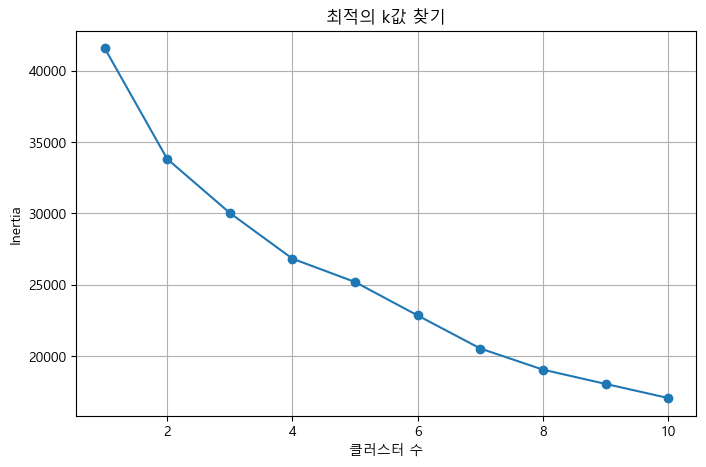

C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


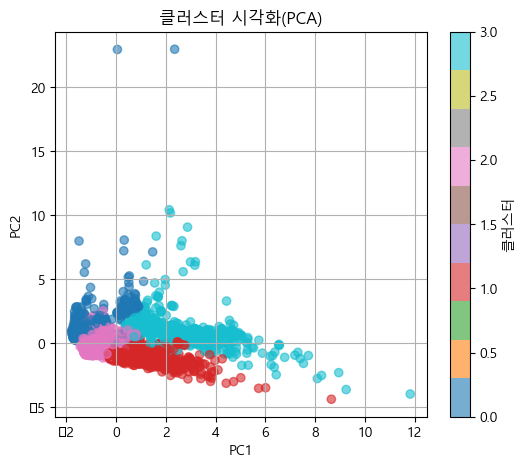

cluster
2    2005
1     778
3     702
0     673
Name: count, dtype: int64


In [24]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 📌 Load your DataFrame (assuming it's already loaded as df)
# df = pd.read_csv("your_file.csv")  # If you're loading from a file

# Step 1. Copy to avoid altering original
df_clust = merged_df.copy()

# Step 2. Label encode categorical columns
categorical_cols = ['서비스명', '판매자', '대분류', '프리미엄 서비스 가입여부', '신속 알람 서비스 사용여부']
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clust[col] = le.fit_transform(df_clust[col])
    le_dict[col] = le

# Step 3. Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clust)

# Step 4. Elbow method to determine optimal K
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('최적의 k값 찾기')
plt.xlabel('클러스터 수')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Step 5. Choose optimal K (say k=4) and fit final KMeans
optimal_k = 4  # or choose based on elbow
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clust['cluster'] = kmeans_final.fit_predict(scaled_data)

# Step 6. Visualize with PCA (2D)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.figure(figsize=(6, 5))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df_clust['cluster'], cmap='tab10', alpha=0.6)
plt.title('클러스터 시각화(PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='클러스터')
plt.grid(True)
plt.show()

# Optional: Check cluster counts
print(df_clust['cluster'].value_counts())


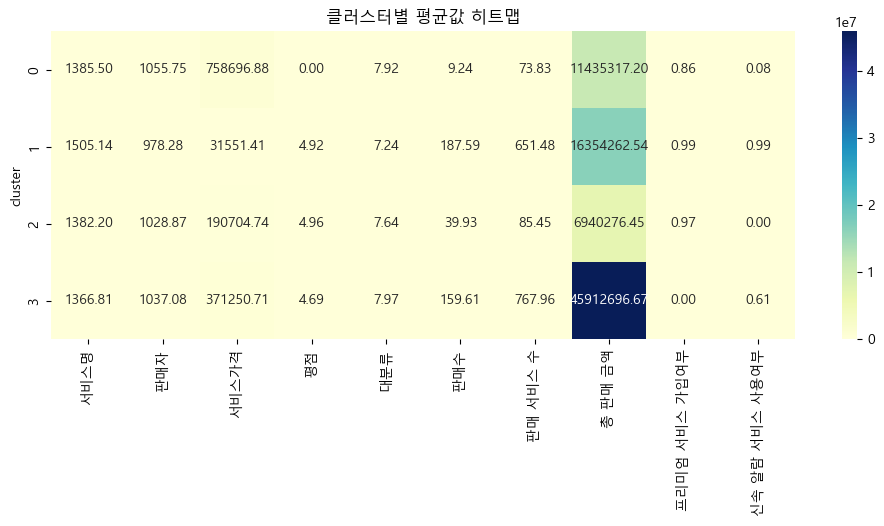

In [31]:
# 클러스터별 평균값 분석
cluster_summary = df_clust.groupby('cluster').mean(numeric_only=True)
import seaborn as sns
import matplotlib.pyplot as plt

# 클러스터별 평균값 히트맵. 수치형자료와 프리미엄 및 서비스 가입여부만 활용
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.figure(figsize=(12, 4))
sns.heatmap(cluster_summary, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("클러스터별 평균값 히트맵")
plt.show()


| 클러스터          | 데이터 수 | 주요 특성 요약                                    |
| ------------- | ----- | ------------------------------------------- |
| **Cluster 0** | 673건  | 평균 서비스가격이 가장 높고, 총 판매 금액도 높음. → **고가·고수익형** |
| **Cluster 1** | 778건  | 평점 높고 프리미엄/알람 서비스 비율 높음. → **서비스 충성도형**     |
| **Cluster 2** | 2005건 | 평균 서비스가격, 판매수, 총 판매금액 모두 중간 → **일반형 (대다수)** |
| **Cluster 3** | 702건  | 서비스가격 낮고 판매수도 적음 → **저가형/신규 판매자**           |


* 고가고수익형은 이미 서비스가격이 높으므로 이탈방지위해 이미 가입한 프리미엄 서비스를 확장필요하며, 거래활성화를 위해 신속알람서비스 사용권장 필요. 다면 평점이 없는 경우가 많아 양질의 서비스를 제공하고 있다고 보기 힘든 상황으로 이용자 만족도를 높일 수 있는 컨설팅 자료 제공 검토 필요
* 서비스충성도 형은 평점이 좋고 알람서비스 사용비율이 높아 이미 적극적으로 L사를 활용하는 전문가로서 이들을 대상으로 L사 서비스 개선에 대한 요구사항을 접수하여 적극적으로 개선 필요. 이들은 평점에 비해 낮은 서비스가격을 제시하고 있는 전문가들로서 적정 서비스가격에 대한 제안 필요
* 일반형은 다른 클러스트에 비해 특별한 점은 발견되지 않아 섣부른 접근을 통하기보다, 일반형 내에서 세부적으로 분류 및 검토하여 시장대비 과도한 가격을 제시하거나, 저조한 평점이나 판매수를 기록하고 있다면 맞춤형 권고 필요 
* 저가형/신규형 판매자는 향후 시장의 기대에 비해 높은 서비스 가격을 제시하였으나, 평점이 낮은 서비스를 제공하고 있는 전문가들로서 향후 지속가능한 수익을 실현하기 위해 현실에 맞는 서비스 가격 인하 검토를 권고할 필요가 있으며 신규형 판매자에게는 구글 트렌드와 같은 향후 IT서비스관련 트렌드를 제공하여 미래 L사의 서비스충성도 높은 판매자로서 이동할 수 있도록 도울 필요가 있음. 

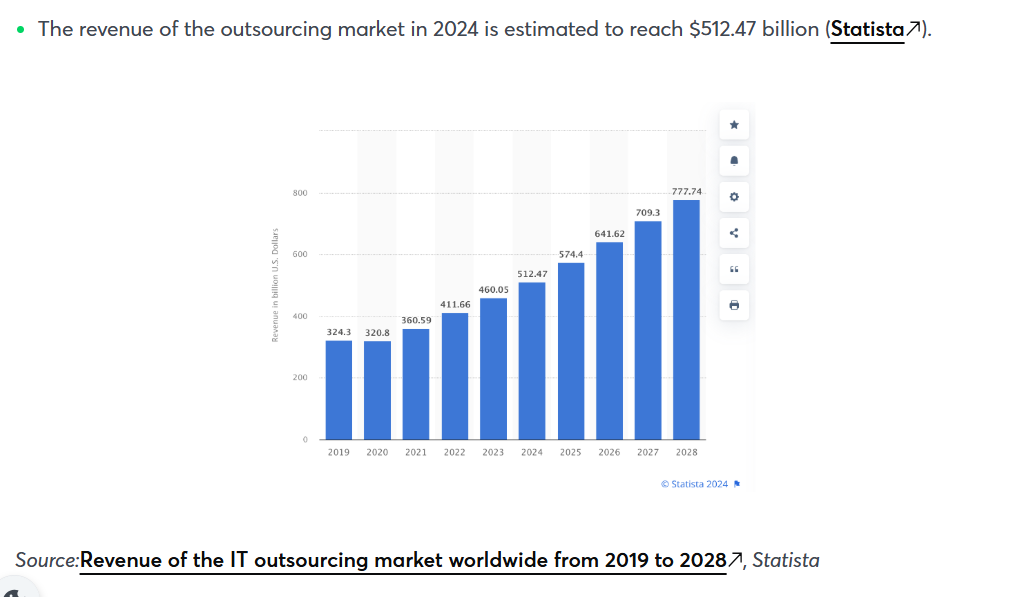

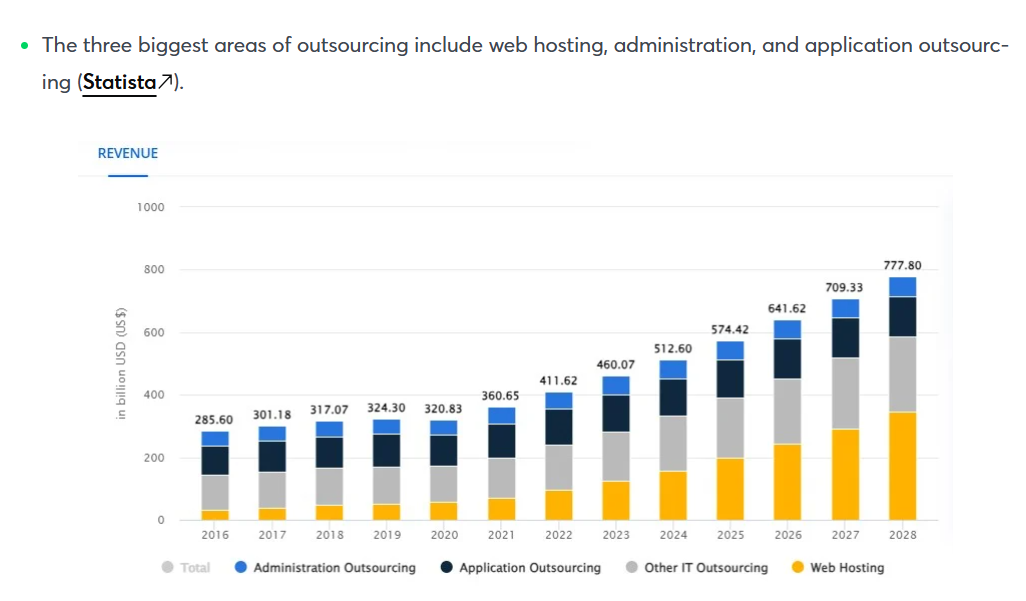

https://www.netguru.com/blog/top-it-outsourcing-trends